
#COMPARAÇÃO DE CLASSIFICADORES
##Dataset : PlantVillage
##Culturas: Tomate, Batata, Pimentão

Pipeline:
  1. Download
  2. Classificadores clássicos com features de visão computacional:Mahalanobis, KNN, SVM e RandomForest
  3. Deep Learning com Transfer Learning: MobileNetV2 e ResNet50
  4. Segmentação de severidade foliar por cor (HSV)
  5. Comparação final de acurácia e tempo de treinamento


In [13]:
# IMPORTS
import os
import cv2
import shutil
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import tensorflow as tf

from skimage.feature import local_binary_pattern
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

from google.colab import drive
drive.mount('/content/drive')

# CONFIGURAÇÕES GLOBAIS
EXIBIR_LOGS = True
IMAGE_SIZE = 256
MAX_IMAGENS_POR_CLASSE = 250
BLOCOS_POR_IMAGEM = 200
TAMANHO_BLOCO = 16
N_AMOSTRAS_VIS = 5
FORCAR_RETREINAMENTO = False
NOME_MODELO_MOBILE = "/content/drive/MyDrive/modelo_mobilenetv2.keras"
NOME_MODELO_RESNET = "/content/drive/MyDrive/modelo_resnet50.keras"
DATASET_LIMITADO = "dataset_limitado"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##BLOCO 1 - FUNÇÕES CLÁSSICAS (pré-processamento, extração de features, visualização)

In [14]:

# Pré-processamento de imagem
def carregar_imagem(path: str) -> np.ndarray | None:
    """
    Lê uma imagem do disco, redimensiona para IMAGE_SIZE×IMAGE_SIZE
    e converte de BGR para HSV.

    O espaço HSV facilita a separação de folha e fundo pelo canal H (matiz),
    e separa luminosidade (V) da cor propriamente dita.
    """
    img = cv2.imread(path)
    if img is None:
        return None
    img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    return img


def remover_fundo(img: np.ndarray) -> np.ndarray:
    """
    Gera uma máscara booleana que isola a folha do fundo da imagem.

    Estratégia: pixels com matiz (H) entre 5° e 160° cobrem desde
    tons amarelo-esverdeados até azul-ciano, excluindo o fundo branco/preto
    que cai fora dessa faixa.
    """
    h = img[:, :, 0]
    return (h >= 5) & (h <= 160)


def extrair_features(img: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """
    Divide a imagem em blocos de TAMANHO_BLOCO×TAMANHO_BLOCO px e extrai
    estatísticas de cor HSV de cada bloco que esteja majoritariamente
    sobre a folha (≥ 80 % dos pixels na máscara).

    Para cada bloco válido calcula, por canal: média, desvio-padrão,
    mínimo, máximo e mediana → vetor de 15 valores por bloco.
    """
    features = []
    h, w, _  = img.shape

    for y in range(0, h - TAMANHO_BLOCO, TAMANHO_BLOCO):
        for x in range(0, w - TAMANHO_BLOCO, TAMANHO_BLOCO):
            bloco      = img[y:y + TAMANHO_BLOCO, x:x + TAMANHO_BLOCO]
            bloco_mask = mask[y:y + TAMANHO_BLOCO, x:x + TAMANHO_BLOCO]

            # Descarta blocos com menos de 80 % de pixels sobre folha
            if np.mean(bloco_mask) < 0.80:
                continue

            pixels = bloco.reshape(-1, 3)
            features.append(np.concatenate([
                pixels.mean(axis=0),    # média por canal
                pixels.std(axis=0),     # desvio-padrão por canal
                pixels.min(axis=0),     # mínimo por canal
                pixels.max(axis=0),     # máximo por canal
                np.median(pixels, axis=0),  # mediana por canal
            ]))

    return np.array(features)


def extrair_lbp(img_gray: np.ndarray) -> np.ndarray:
    """
    Calcula o histograma normalizado de Local Binary Patterns (LBP)
    sobre a imagem em escala de cinza.

    LBP captura textura local: manchas, lesões e padrões foliares
    produzem assinaturas de textura distintas que complementam as
    features de cor.

    Configuração: 8 vizinhos em raio 1, método 'uniform', 10 bins.
    """
    lbp        = local_binary_pattern(img_gray, P=8, R=1, method="uniform")
    hist, _    = np.histogram(lbp, bins=10, range=(0, 10), density=True)
    return hist


def criar_feature_global(path_img: str) -> np.ndarray | None:
    """
    Pipeline completo de extração de features para classificadores clássicos.

    Etapas:
      1. Carrega e converte a imagem para HSV
      2. Remove o fundo pela máscara de matiz
      3. Extrai estatísticas de blocos válidos
      4. Amostra aleatoriamente até BLOCOS_POR_IMAGEM blocos
      5. Calcula histograma LBP sobre a versão em cinza
      6. Concatena: média dos blocos, desvio dos blocos, LBP
    """
    img = carregar_imagem(path_img)
    if img is None:
        return None

    mask     = remover_fundo(img)
    features = extrair_features(img, mask)

    if len(features) == 0:
        return None

    # Amostragem sem reposição para fixar o número de blocos
    idx      = np.random.choice(len(features), min(BLOCOS_POR_IMAGEM, len(features)), replace=False)
    features = features[idx]

    # LBP calculado sobre a imagem original em cinza (não HSV)
    img_gray = cv2.cvtColor(cv2.imread(path_img), cv2.COLOR_BGR2GRAY)
    img_gray = cv2.resize(img_gray, (IMAGE_SIZE, IMAGE_SIZE))
    lbp_feat = extrair_lbp(img_gray)

    return np.concatenate([features.mean(axis=0), features.std(axis=0), lbp_feat])


# Visualização de predições (classificadores clássicos)
def visualizar_previsoes(
    y_real:      np.ndarray,
    y_previsto:  np.ndarray,
    paths_imgs:  np.ndarray,
    titulo:      str,
    n:           int = N_AMOSTRAS_VIS,
) -> None:
    """
    Exibe uma grade com N amostras aleatórias do conjunto de teste,
    destacando acertos (borda verde) e erros (borda vermelha).

    Parâmetros
    y_real     : rótulos verdadeiros
    y_previsto : rótulos preditos pelo modelo
    paths_imgs : caminhos das imagens correspondentes
    titulo     : título da figura (também usado no nome do arquivo)
    n          : número de amostras a exibir
    """
    indices = np.random.choice(len(paths_imgs), n, replace=False)

    fig, axes = plt.subplots(1, n, figsize=(4 * n, 5))
    fig.suptitle(titulo, fontsize=13, fontweight="bold")

    for i, idx in enumerate(indices):
        img = cv2.imread(paths_imgs[idx])
        img = cv2.resize(img, (256, 256))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        real    = y_real[idx]
        prev    = y_previsto[idx]
        acertou = real == prev
        cor     = "#2ecc71" if acertou else "#e74c3c"
        status  = "✓ ACERTO" if acertou else "X ERRO"

        ax = axes[i]
        ax.imshow(img)
        ax.axis("off")

        # Borda colorida ao redor da imagem indica acerto/erro
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor(cor)
            spine.set_linewidth(5)

        ax.set_title(
            f"{status}\nReal: {real}\nPrevisto: {prev}",
            fontsize=8, color=cor, fontweight="bold",
        )

    plt.tight_layout()
    nome_arquivo = titulo.replace(" ", "_").replace(":", "") + ".png"
    plt.savefig(nome_arquivo, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Salvo: {nome_arquivo}")

### Classificador de Mahalanobis


In [15]:

class MahalanobisClassifier:
    """
    Classificador por Distância de Mahalanobis.

    Diferente da distância euclidiana, Mahalanobis leva em conta a
    covariância entre features, tornando-se invariante à escala e à
    correlação entre dimensões. Classifica cada amostra na classe de menor
    distância de Mahalanobis.
    """

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        """
        Estima os parâmetros de cada classe.
        """
        self.classes_ = np.unique(y)
        self.modelos  = {}

        for classe in self.classes_:
            X_classe = X[y == classe]
            media = np.mean(X_classe, axis=0)
            cov = np.cov(X_classe.T) + np.eye(X_classe.shape[1]) * 1e-5
            inv_cov = np.linalg.inv(cov)
            self.modelos[classe] = {"media": media, "inv_cov": inv_cov}

    def _distancia_mahalanobis(
        self,
        x:       np.ndarray,
        media:   np.ndarray,
        inv_cov: np.ndarray,
    ) -> float:
        diff = x - media
        return np.sqrt(diff.T @ inv_cov @ diff)

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Classifica cada amostra na classe de menor distância de Mahalanobis.
        """
        predicoes = []
        for x in X:
            menor_dist    = float("inf")
            melhor_classe = None
            for classe, modelo in self.modelos.items():
                dist = self._distancia_mahalanobis(x, modelo["media"], modelo["inv_cov"])
                if dist < menor_dist:
                    menor_dist    = dist
                    melhor_classe = classe
            predicoes.append(melhor_classe)
        return np.array(predicoes)

## BLOCO 2 - FUNÇÕES DEEP LEARNING (segmentação foliar, diagnóstico, treino/carga de modelos)

In [16]:

# Segmentação de severidade da doença por cor (HSV)
def extrair_severidade_foliar(
    caminho_imagem: str,
) -> tuple[float, np.ndarray, np.ndarray] | None:
    """
    Estima a severidade da doença em uma folha usando limiarização HSV.

    Abordagem:
      - Tecido saudável : tom verde (H 25–90, S/V altos)
      - Lesão / doença  : tom amarelo-alaranjado (H 10–24), típico de
                          manchas necróticas e cloróticas

    A severidade é a proporção de pixels de lesão sobre o total de
    tecido detectado (verde + lesão), expressa em porcentagem.

    """
    if EXIBIR_LOGS:
        print(f"Segmentando: {caminho_imagem}")

    imagem = cv2.imread(caminho_imagem)
    if imagem is None:
        if EXIBIR_LOGS:
            print("Falha ao carregar imagem.")
        return None

    hsv = cv2.cvtColor(imagem, cv2.COLOR_BGR2HSV)

    # Faixas HSV calibradas para folhas em condições de laboratório
    baixo_verde  = np.array([25,  40,  40])
    alto_verde   = np.array([90, 255, 255])
    baixo_doenca = np.array([10,  50,  20])
    alto_doenca  = np.array([24, 255, 255])

    mascara_verde  = cv2.inRange(hsv, baixo_verde,  alto_verde)
    mascara_doenca = cv2.inRange(hsv, baixo_doenca, alto_doenca)

    pixels_saudaveis     = cv2.countNonZero(mascara_verde)
    pixels_doentes       = cv2.countNonZero(mascara_doenca)
    pixels_totais_tecido = pixels_saudaveis + pixels_doentes

    severidade = (pixels_doentes / pixels_totais_tecido) * 100 \
                 if pixels_totais_tecido > 0 else 0.0

    if EXIBIR_LOGS:
        print(
            f"Área saudável: {pixels_saudaveis}px | "
            f"Lesão: {pixels_doentes}px | "
            f"Severidade: {severidade:.2f}%"
        )

    return severidade, mascara_verde, mascara_doenca


# Diagnóstico fitopatológico com tradução de rótulos
def classificar_patogeno(
    caminho_img: str,
    modelo:      tf.keras.Model,
    classes:     list[str],
) -> tuple[str, float, str]:
    """
    Classifica uma imagem com o modelo de deep learning e traduz o
    rótulo original do PlantVillage para um
    diagnóstico legível em português.
    """
    img       = tf.keras.utils.load_img(caminho_img, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)
    img_lote  = np.expand_dims(img_array, axis=0)

    predicoes       = modelo.predict(img_lote, verbose=0)
    indice_predicao = np.argmax(predicoes[0])
    classe_original = classes[indice_predicao].lower()

    # Identificação da cultura
    if "pepper" in classe_original:
        cultura = "Pimentão"
    elif "potato" in classe_original:
        cultura = "Batata"
    elif "tomato" in classe_original:
        cultura = "Tomate"
    else:
        cultura = "Desconhecida"

    # Identificação do patógeno
    if "healthy" in classe_original:
        diagnostico = "Saudável"
    elif "bacterial" in classe_original:
        diagnostico = "Mancha Bacteriana"
    elif "early" in classe_original:
        diagnostico = "Pinta Preta"
    elif "late" in classe_original:
        diagnostico = "Requeima"
    elif "mold" in classe_original:
        diagnostico = "Bolor Foliar"
    elif "septoria" in classe_original:
        diagnostico = "Mancha de Septoria"
    elif "mite" in classe_original or "spider" in classe_original:
        diagnostico = "Ácaro Rajado"
    elif "target" in classe_original:
        diagnostico = "Mancha Alvo"
    elif "yellow" in classe_original or "curl" in classe_original:
        diagnostico = "Vírus do Mosaico Amarelo"
    elif "mosaic" in classe_original:
        diagnostico = "Vírus do Mosaico"
    else:
        # Fallback: formata o rótulo bruto de forma legível
        diagnostico = classe_original.replace("_", " ").title()

    classe_traduzida = f"Cultura: {cultura} | Patógeno: {diagnostico}"
    confianca        = predicoes[0][indice_predicao] * 100

    return classe_traduzida, confianca, classes[indice_predicao]


# Data augmentation compartilhado entre todos os modelos DL

aumento_dados = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
], name="aumento_dados")


def treinar_ou_carregar_modelo(
    nome_arquivo:        str,
    modelo_base:         tf.keras.Model,
    fn_preprocessamento,
    nome_exibicao:       str,
) -> tf.keras.Model:
    """
    Carrega um modelo salvo ou treina um novo usando Transfer Learning
    com MobileNetV2 ou ResNet50. O backbone pré-treinado permanece
    congelado e apenas a camada de classificação é treinada. Após o
    treinamento, o modelo é avaliado e suas métricas são registradas.

    Retorna o modelo pronto para inferência.
    """

    print(f"\nProcurando modelo em: {nome_arquivo}")
    print("Existe?", os.path.exists(nome_arquivo))

    if os.path.exists(nome_arquivo) and not FORCAR_RETREINAMENTO:
        print("Modelo encontrado! Carregando...")
        modelo = tf.keras.models.load_model(nome_arquivo)
        tempo_treino = 0.0

    else:
        if EXIBIR_LOGS:
            print(f"\nTreinando {nome_exibicao} do zero...")

        modelo_base.trainable = False  # Congela pesos pré-treinados no ImageNet

        entradas = tf.keras.Input(shape=(224, 224, 3))
        x = aumento_dados(entradas)
        x = fn_preprocessamento(x)
        x = modelo_base(x, training=False)
        x = GlobalAveragePooling2D()(x)
        saidas = Dense(numero_classes, activation="softmax")(x)

        modelo = Model(entradas, saidas)
        modelo.compile(
            optimizer="adam",
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"],
        )

        t0 = time.time()
        modelo.fit(
            dataset_treino,
            validation_data=dataset_validacao,
            epochs=8,
            verbose=1,
        )
        tempo_treino = time.time() - t0

        modelo.save(nome_arquivo)
        print(f"Modelo salvo em: {nome_arquivo}")
        print("Arquivo existe?", os.path.exists(nome_arquivo))
        if EXIBIR_LOGS:
            print(f"Modelo salvo em: {nome_arquivo}")

    # Avaliação no conjunto de validação
    y_true, y_pred_idx = [], []
    t0 = time.time()
    for imagens_lote, labels_lote in dataset_validacao:
        preds = modelo.predict(imagens_lote, verbose=0)
        y_pred_idx.extend(np.argmax(preds, axis=1))
        y_true.extend(labels_lote.numpy())
    tempo_inf = time.time() - t0

    acc = accuracy_score(y_true, y_pred_idx)

    # Registra na lista global para a tabela comparativa final
    resultados.append({
        "Modelo":           nome_exibicao,
        "Tipo":             "Deep Learning",
        "Accuracy (%)":     round(acc * 100, 2),
        "Tempo Treino (s)": round(tempo_treino, 1),
        "Tempo Inf. (s)":   round(tempo_inf, 2),
    })

    if EXIBIR_LOGS:
        print(f"{nome_exibicao}: Accuracy = {acc * 100:.2f}%")

    return modelo


# EXECUÇÃO PRINCIPAL


##ETAPA 1 — Download e limitação do dataset

In [17]:

if EXIBIR_LOGS:
    print("Verificando e baixando o dataset...")

path = kagglehub.dataset_download("emmarex/plantdisease")

if EXIBIR_LOGS:
    print(f"Dataset disponível em: {path}")

# Localiza o subdiretório que contém as classes
caminho_base = path
for raiz, diretorios, arquivos in os.walk(path):
    if len(diretorios) > 10:
        caminho_base = raiz
        break

if EXIBIR_LOGS:
    print(f"Diretório base: {caminho_base}")
    print(f"Subpastas encontradas: {os.listdir(caminho_base)}")

# Recria a pasta local com no máximo MAX_IMAGENS_POR_CLASSE por classe
if os.path.exists(DATASET_LIMITADO):
    shutil.rmtree(DATASET_LIMITADO)
os.makedirs(DATASET_LIMITADO)

for classe in sorted(os.listdir(caminho_base)):
    pasta_origem = os.path.join(caminho_base, classe)
    if not os.path.isdir(pasta_origem):
        continue
    pasta_destino = os.path.join(DATASET_LIMITADO, classe)
    os.makedirs(pasta_destino)
    imagens = sorted([
        arq for arq in os.listdir(pasta_origem)
        if arq.lower().endswith((".jpg", ".jpeg", ".png"))
    ])[:MAX_IMAGENS_POR_CLASSE]
    for img in imagens:
        shutil.copy2(
            os.path.join(pasta_origem, img),
            os.path.join(pasta_destino, img),
        )

caminho_base = DATASET_LIMITADO

print("\nVerificando dataset limitado:")
for classe in os.listdir(caminho_base):
    pasta = os.path.join(caminho_base, classe)
    if os.path.isdir(pasta):
        print(f"  {classe}: {len(os.listdir(pasta))} imagens")

if EXIBIR_LOGS:
    print(f"Usando no máximo {MAX_IMAGENS_POR_CLASSE} imagens por classe")


Verificando e baixando o dataset...
Using Colab cache for faster access to the 'plantdisease' dataset.
Dataset disponível em: /kaggle/input/plantdisease
Diretório base: /kaggle/input/plantdisease/PlantVillage
Subpastas encontradas: ['Pepper__bell___Bacterial_spot', 'Potato___healthy', 'Tomato_Leaf_Mold', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Bacterial_spot', 'Tomato_Septoria_leaf_spot', 'Tomato_healthy', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Early_blight', 'Tomato__Target_Spot', 'Pepper__bell___healthy', 'Potato___Late_blight', 'Tomato_Late_blight', 'Potato___Early_blight', 'Tomato__Tomato_mosaic_virus']

Verificando dataset limitado:
  Tomato__Target_Spot: 250 imagens
  Tomato__Tomato_mosaic_virus: 250 imagens
  Potato___Late_blight: 250 imagens
  Tomato_healthy: 250 imagens
  Tomato__Tomato_YellowLeaf__Curl_Virus: 250 imagens
  Tomato_Spider_mites_Two_spotted_spider_mite: 250 imagens
  Tomato_Early_blight: 250 imagens
  Pepper__bell___healthy: 250 imagens


## ETAPA 2 — Classificadores clássicos

In [18]:

classes = sorted([
    d for d in os.listdir(caminho_base)
    if os.path.isdir(os.path.join(caminho_base, d))
])

if EXIBIR_LOGS:
    print(f"\n{len(classes)} classes encontradas.")

# Extração de features
if EXIBIR_LOGS:
    print("=" * 60)
    print("CRIANDO DATASET (features clássicas)")
    print("=" * 60)

X, y, paths = [], [], []

for classe in classes:
    if EXIBIR_LOGS:
        print(f"\nClasse: {classe}")

    pasta = os.path.join(caminho_base, classe)
    if not os.path.exists(pasta):
        print(f"  AVISO: pasta não encontrada -> {pasta}")
        continue

    imagens       = os.listdir(pasta)[:MAX_IMAGENS_POR_CLASSE]
    total_validas = 0

    for nome_img in imagens:
        path_img = os.path.join(pasta, nome_img)
        feature  = criar_feature_global(path_img)
        if feature is None:
            continue
        X.append(feature)
        y.append(classe)
        paths.append(path_img)
        total_validas += 1

    if EXIBIR_LOGS:
        print(f"  Imagens válidas: {total_validas}")

X     = np.array(X)
y     = np.array(y)
paths = np.array(paths)

classes_carregadas = np.unique(y).tolist()

if EXIBIR_LOGS:
    print(f"\nShape X: {X.shape} | Shape y: {y.shape}")
    print(f"Classes carregadas: {len(classes_carregadas)}")

# Split treino/teste estratificado + normalização z-score
X_train, X_test, y_train, y_test, paths_train, paths_test = train_test_split(
    X, y, paths, test_size=0.2, random_state=42, stratify=y
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Definição dos modelos clássicos
modelos_classicos = {
    "Mahalanobis":  MahalanobisClassifier(),
    "KNN":          KNeighborsClassifier(n_neighbors=5),
    "SVM":          SVC(kernel="rbf", probability=True),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
}

resultados = []  # Acumula métricas de todos os modelos para a comparação final

for nome_modelo, modelo in modelos_classicos.items():

    if EXIBIR_LOGS:
        print("\n" + "=" * 60)
        print(f"MODELO: {nome_modelo}")
        print("=" * 60)

    t0 = time.time()
    modelo.fit(X_train, y_train)
    tempo_treino = time.time() - t0

    t0 = time.time()
    y_pred = modelo.predict(X_test)
    tempo_inf = time.time() - t0

    accuracy = accuracy_score(y_test, y_pred)

    resultados.append({
        "Modelo":           nome_modelo,
        "Tipo":             "Clássico",
        "Accuracy (%)":     round(accuracy * 100, 2),
        "Tempo Treino (s)": round(tempo_treino, 1),
        "Tempo Inf. (s)":   round(tempo_inf, 2),
    })

    if EXIBIR_LOGS:
        print(f"\nAccuracy: {accuracy * 100:.2f}%")
        print(classification_report(y_test, y_pred, labels=classes_carregadas))

    # Matriz de confusão
    matriz  = confusion_matrix(y_test, y_pred, labels=classes_carregadas)
    fig, ax = plt.subplots(figsize=(14, 12))
    im      = ax.imshow(matriz, interpolation="nearest", cmap="Blues")
    plt.colorbar(im, ax=ax)

    ax.set_xticks(range(len(classes_carregadas)))
    ax.set_yticks(range(len(classes_carregadas)))
    ax.set_xticklabels(classes_carregadas, rotation=45, ha="right", fontsize=7)
    ax.set_yticklabels(classes_carregadas, fontsize=7)

    for i in range(len(classes_carregadas)):
        for j in range(len(classes_carregadas)):
            cor = "white" if matriz[i, j] > matriz.max() / 2 else "black"
            ax.text(j, i, str(matriz[i, j]), ha="center", va="center", fontsize=7, color=cor)

    ax.set_xlabel("Previsto", fontsize=11)
    ax.set_ylabel("Real", fontsize=11)
    ax.set_title(f"Matriz de Confusão — {nome_modelo}", fontsize=13, fontweight="bold")
    plt.tight_layout()

    nome_matriz = f"matriz_{nome_modelo}.png"
    plt.savefig(nome_matriz, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Salvo: {nome_matriz}")

    visualizar_previsoes(y_test, y_pred, paths_test, titulo=f"Modelo: {nome_modelo}")

Output hidden; open in https://colab.research.google.com to view.

## ETAPA 3 — Preparação dos datasets para Deep Learning

In [19]:

if EXIBIR_LOGS:
    print("Carregando datasets de treino e validação (DL)...")

tamanho_lote   = 32
tamanho_imagem = (224, 224)

dataset_treino = tf.keras.utils.image_dataset_from_directory(
    caminho_base,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=tamanho_imagem,
    batch_size=tamanho_lote,
)

dataset_validacao = tf.keras.utils.image_dataset_from_directory(
    caminho_base,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=tamanho_imagem,
    batch_size=tamanho_lote,
)

nomes_classes  = dataset_treino.class_names
numero_classes = len(nomes_classes)

if EXIBIR_LOGS:
    print(f"{numero_classes} classes mapeadas.")

# Grade de exemplos por classe
imagens_por_classe = {}
for raiz, diretorios, arquivos in os.walk(caminho_base):
    nome_classe = os.path.basename(raiz)
    if nome_classe in nomes_classes:
        for arquivo in arquivos:
            if arquivo.lower().endswith((".png", ".jpg", ".jpeg")):
                imagens_por_classe[nome_classe] = os.path.join(raiz, arquivo)
                break

colunas = 4
linhas  = -(-numero_classes // colunas)
figura, eixos = plt.subplots(linhas, colunas, figsize=(16, linhas * 4))
eixos = eixos.flatten()

for i, classe in enumerate(nomes_classes):
    if classe in imagens_por_classe:
        img     = cv2.imread(imagens_por_classe[classe])
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        eixos[i].imshow(img_rgb)
    else:
        eixos[i].set_facecolor("black")
    nome_formatado = classe.replace("___", "\n").replace("__", "\n").replace("_", " ")
    eixos[i].set_title(nome_formatado, fontsize=8)
    eixos[i].axis("off")

for j in range(numero_classes, len(eixos)):
    eixos[j].set_visible(False)

plt.suptitle(f"PlantVillage — {numero_classes} Classes", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("classes_dataset.png", dpi=100, bbox_inches="tight")
plt.show()

Output hidden; open in https://colab.research.google.com to view.

## ETAPA 4 — Visualização da segmentação de severidade

Imagem de teste: /kaggle/input/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot/0f72db9c-d635-4415-9781-68937328aed2___NREC_B.Spot 9188.JPG
Segmentando: /kaggle/input/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot/0f72db9c-d635-4415-9781-68937328aed2___NREC_B.Spot 9188.JPG
Área saudável: 20415px | Lesão: 2081px | Severidade: 9.25%


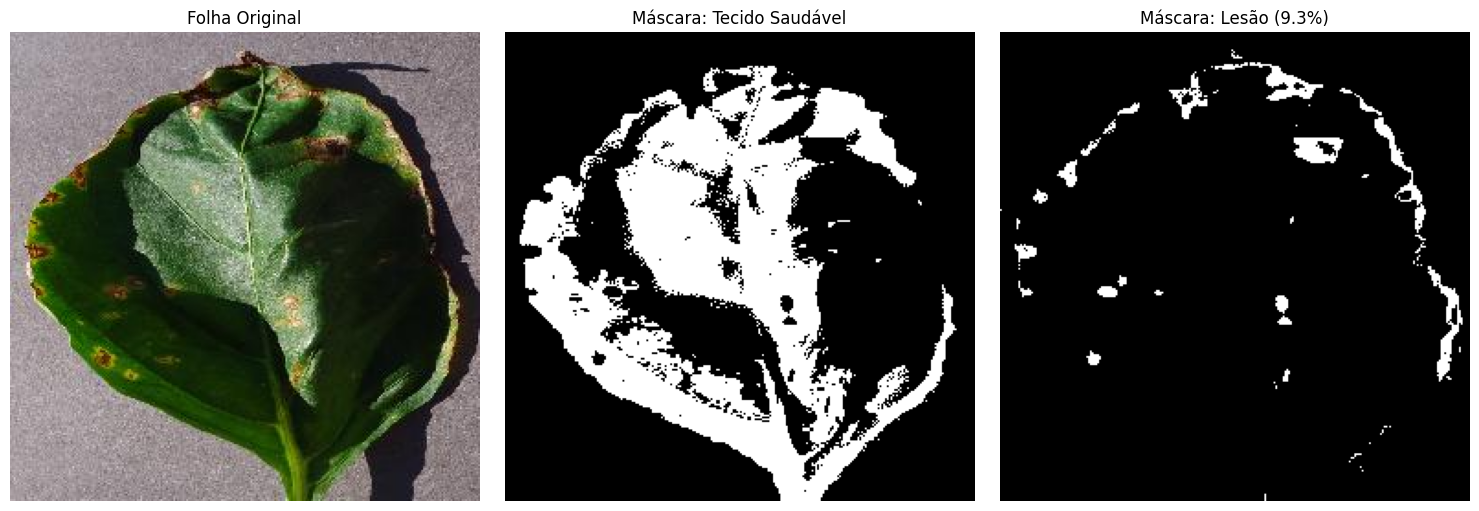

In [20]:
# Localiza uma imagem de teste qualquer
caminho_imagem_teste = None
for raiz, diretorios, arquivos in os.walk(path):
    for arquivo in arquivos:
        if arquivo.lower().endswith((".png", ".jpg", ".jpeg")):
            caminho_imagem_teste = os.path.join(raiz, arquivo)
            break
    if caminho_imagem_teste:
        break

if EXIBIR_LOGS:
    print(f"Imagem de teste: {caminho_imagem_teste}" if caminho_imagem_teste
          else "Nenhuma imagem encontrada.")

if caminho_imagem_teste is not None:
    resultado = extrair_severidade_foliar(caminho_imagem_teste)

    if resultado is not None:
        severidade, mascara_verde, mascara_doenca = resultado
        imagem_rgb = cv2.cvtColor(cv2.imread(caminho_imagem_teste), cv2.COLOR_BGR2RGB)

        figura, eixos = plt.subplots(1, 3, figsize=(15, 5))
        eixos[0].imshow(imagem_rgb);         eixos[0].set_title("Folha Original");            eixos[0].axis("off")
        eixos[1].imshow(mascara_verde,  cmap="gray"); eixos[1].set_title("Máscara: Tecido Saudável"); eixos[1].axis("off")
        eixos[2].imshow(mascara_doenca, cmap="gray"); eixos[2].set_title(f"Máscara: Lesão ({severidade:.1f}%)"); eixos[2].axis("off")
        plt.tight_layout()
        plt.show()


## ETAPA 5 — Treino / carga dos modelos de Deep Learning


In [21]:

# MobileNetV2: treinada uma única vez (ou carregada do cache)
modelo_mobilenet = treinar_ou_carregar_modelo(
    nome_arquivo        = NOME_MODELO_MOBILE,
    modelo_base         = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet"),
    fn_preprocessamento = tf.keras.applications.mobilenet_v2.preprocess_input,
    nome_exibicao       = "MobileNetV2",
)

# ResNet50: mesma lógica de cache
modelo_resnet = treinar_ou_carregar_modelo(
    nome_arquivo        = NOME_MODELO_RESNET,
    modelo_base         = ResNet50(input_shape=(224, 224, 3), include_top=False, weights="imagenet"),
    fn_preprocessamento = tf.keras.applications.resnet.preprocess_input,
    nome_exibicao       = "ResNet50",
)




Procurando modelo em: /content/drive/MyDrive/modelo_mobilenetv2.keras
Existe? True
Modelo encontrado! Carregando...
MobileNetV2: Accuracy = 82.60%

Procurando modelo em: /content/drive/MyDrive/modelo_resnet50.keras
Existe? True
Modelo encontrado! Carregando...
ResNet50: Accuracy = 89.45%


## ETAPA 6 — Diagnóstico em imagem única


In [22]:

if caminho_imagem_teste is not None:
    diagnostico, confianca, _ = classificar_patogeno(
        caminho_imagem_teste, modelo_mobilenet, nomes_classes
    )
    if EXIBIR_LOGS:
        print(f"Diagnóstico : {diagnostico}")
        print(f"Confiança   : {confianca:.2f}%")


Diagnóstico : Cultura: Pimentão | Patógeno: Mancha Bacteriana
Confiança   : 93.13%


## ETAPA 7 — Processamento em lote: uma imagem por classe


In [23]:

if EXIBIR_LOGS:
    print("Processando uma amostra por classe...")

amostras_selecionadas = []
for raiz, diretorios, arquivos in os.walk(caminho_base):
    nome_classe = os.path.basename(raiz)
    if nome_classe in nomes_classes:
        for arquivo in arquivos:
            if arquivo.lower().endswith((".png", ".jpg", ".jpeg")):
                amostras_selecionadas.append(os.path.join(raiz, arquivo))
                break

if EXIBIR_LOGS:
    print(f"{len(amostras_selecionadas)} amostras selecionadas.")

figura, eixos = plt.subplots(
    len(amostras_selecionadas), 2,
    figsize=(10, 4 * len(amostras_selecionadas))
)

if len(amostras_selecionadas) == 1:
    eixos = [eixos]

acertos = 0

for i, caminho_amostra in enumerate(amostras_selecionadas):
    if EXIBIR_LOGS:
        print(f"Amostra {i+1}/{len(amostras_selecionadas)}")

    resultado_cv = extrair_severidade_foliar(caminho_amostra)
    if resultado_cv is None:
        continue

    severidade, mascara_verde, mascara_doenca = resultado_cv
    diagnostico, confianca, classe_prevista   = classificar_patogeno(
        caminho_amostra, modelo_mobilenet, nomes_classes
    )

    classe_real = os.path.basename(os.path.dirname(caminho_amostra))
    acertou     = classe_real.lower() == classe_prevista.lower()
    if acertou:
        acertos += 1

    status = "CORRETO" if acertou else f"ERRADO (era: {classe_real})"
    cor    = "green" if acertou else "red"

    img_rgb = cv2.cvtColor(cv2.imread(caminho_amostra), cv2.COLOR_BGR2RGB)

    eixos[i][0].imshow(img_rgb)
    eixos[i][0].set_title(
        f"{diagnostico}\nConfiança: {confianca:.1f}% — {status}",
        fontsize=9, color=cor,
    )
    eixos[i][0].axis("off")

    eixos[i][1].imshow(mascara_doenca, cmap="gray")
    eixos[i][1].set_title(f"Segmentação da Lesão\nSeveridade: {severidade:.2f}%", fontsize=9)
    eixos[i][1].axis("off")

plt.tight_layout()
plt.savefig("resultado_todas_classes.png", dpi=100, bbox_inches="tight")
plt.show()

if EXIBIR_LOGS:
    total = len(amostras_selecionadas)
    print(f"\nAcurácia na amostra: {acertos}/{total} ({acertos / total * 100:.1f}%)")



Output hidden; open in https://colab.research.google.com to view.

## ETAPA 8 — Comparação final de todos os modelos



COMPARAÇÃO FINAL
      Modelo          Tipo  Accuracy (%)  Tempo Treino (s)  Tempo Inf. (s)
    ResNet50 Deep Learning         89.45               0.0          261.92
 MobileNetV2 Deep Learning         82.60               0.0           42.43
         SVM      Clássico         81.67               3.3            0.33
RandomForest      Clássico         79.07               6.7            0.05
         KNN      Clássico         75.79               0.0            0.03
 Mahalanobis      Clássico         66.89               0.0            0.08


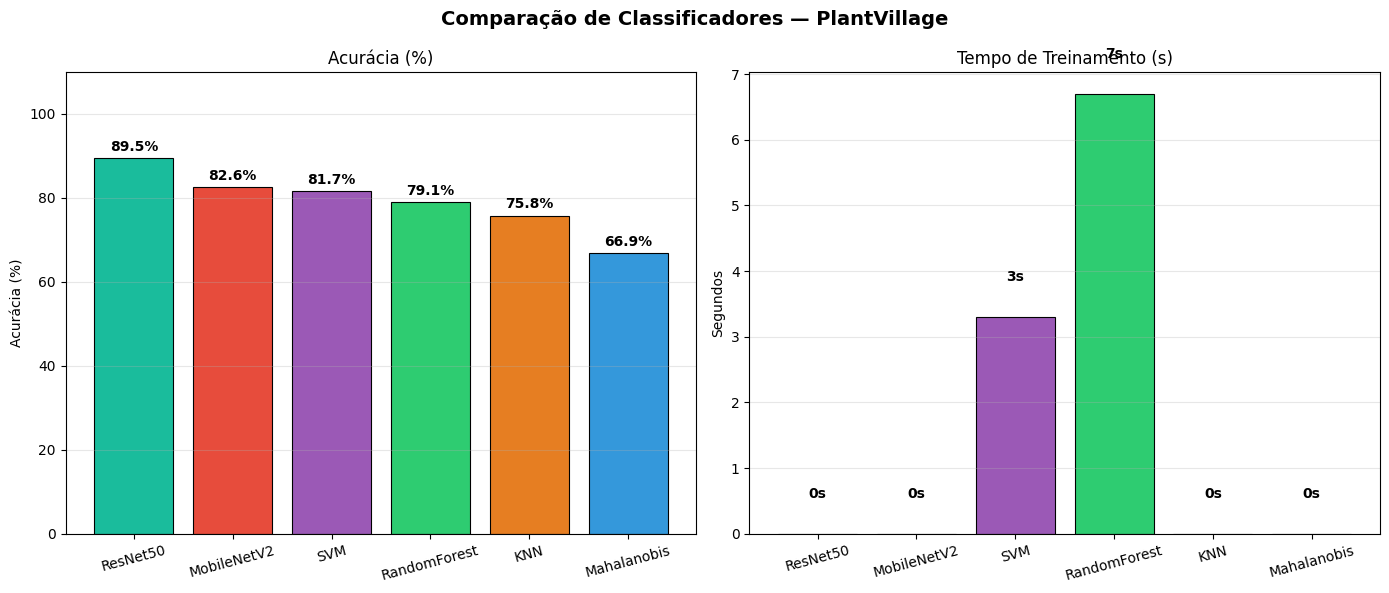

Salvo: comparacao_final.png

Melhor modelo: ResNet50 com 89.45% de acurácia


In [24]:

if EXIBIR_LOGS:
    print("\n" + "=" * 60)
    print("COMPARAÇÃO FINAL")
    print("=" * 60)

resultados_df = pd.DataFrame(resultados).sort_values(by="Accuracy (%)", ascending=False)
print(resultados_df.to_string(index=False))

cores = {
    "Mahalanobis":  "#3498db",
    "KNN":          "#e67e22",
    "SVM":          "#9b59b6",
    "RandomForest": "#2ecc71",
    "MobileNetV2":  "#e74c3c",
    "ResNet50":     "#1abc9c",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Comparação de Classificadores — PlantVillage", fontsize=14, fontweight="bold")

modelos_nomes = resultados_df["Modelo"].tolist()
acuracias     = resultados_df["Accuracy (%)"].tolist()
cores_lista   = [cores.get(m, "#95a5a6") for m in modelos_nomes]

# Gráfico de acurácia
barras = axes[0].bar(modelos_nomes, acuracias, color=cores_lista, edgecolor="black", linewidth=0.8)
axes[0].set_title("Acurácia (%)", fontsize=12)
axes[0].set_ylim(0, 110)
axes[0].set_ylabel("Acurácia (%)")
for bar, val in zip(barras, acuracias):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
        f"{val:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold",
    )

# Gráfico de tempo de treinamento
tempos  = resultados_df["Tempo Treino (s)"].tolist()
barras2 = axes[1].bar(modelos_nomes, tempos, color=cores_lista, edgecolor="black", linewidth=0.8)
axes[1].set_title("Tempo de Treinamento (s)", fontsize=12)
axes[1].set_ylabel("Segundos")
for bar, val in zip(barras2, tempos):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
        f"{val:.0f}s", ha="center", va="bottom", fontsize=10, fontweight="bold",
    )

for ax in axes:
    ax.tick_params(axis="x", rotation=15)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("comparacao_final.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: comparacao_final.png")

if EXIBIR_LOGS:
    melhor = resultados_df.iloc[0]
    print(f"\nMelhor modelo: {melhor['Modelo']} com {melhor['Accuracy (%)']:.2f}% de acurácia")